# Sumativa 1 — MCDI501: Estadística Computacional para la Toma de Decisiones
## Análisis Exploratorio e Inferencial — Dataset: Predict Students' Dropout and Academic Success

**Integrantes:** Cristian Pastén Barraza, Daniel Hormazábal Ocampo<br>
**Docente:** Jean Paul Maidana González<br>
**Fecha:** 03 Julio 2026 <br>
**Repositorio:** https://github.com/DanielParavel/proyecto-grupo10-mcdi501

Semilla utilizada para reproducibilidad: `123456`

Este notebook contiene el código completo del análisis, organizado en los mismos 7 bloques de la plantilla oficial de la Sumativa 1, para que cada sección sea trazable hasta el resultado que la respalda. Entorno: Python 3.11.15 (venv local).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 123456
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn    : {sns.__version__}")
import scipy
print(f"scipy      : {scipy.__version__}")
print("\nLibrerías importadas correctamente ✓")

pandas     : 2.2.2
numpy      : 2.2.6
matplotlib : 3.9.4
seaborn    : 0.13.2
scipy      : 1.15.3

Librerías importadas correctamente ✓


## Introducción

El conjunto de datos utilizado es **"Predict Students' Dropout and Academic Success"** (Realinho, Vieira Martins, Machado & Baptista, 2021), disponible en el UCI Machine Learning Repository (DOI: 10.24432/C5MC89). Reúne información de **4.424 estudiantes** matriculados entre 2008 y 2019 en 17 carreras de pregrado de una institución de educación superior portuguesa, descritos por **37 variables** de tipo demográfico, socioeconómico, académico (al cierre de 1er y 2do semestre) y macroeconómico.

La variable objetivo (`Target`) clasifica a cada estudiante en tres categorías: *Dropout* (abandono), *Enrolled* (matriculado, sin resolución aún) y *Graduate* (titulado). El objetivo es aplicar estadística descriptiva, estimación puntual, intervalos de confianza y pruebas de hipótesis para **identificar los factores que se asocian con mayor fuerza al riesgo de deserción**, como base de evidencia para el diseño de intervenciones tempranas de retención.

In [28]:
df = pd.read_csv('../data/predict_students_dropout_and_academic_success.csv', sep=';')

# Se detectaron nombres de columna con espacios en blanco al final (ej. "Daytime/evening attendance   "),
# heredados del archivo original de UCI. Se documentan y normalizan para evitar errores de referencia por nombre.
columnas_con_espacios = [c for c in df.columns if c != c.strip()]
print(f"Columnas con espacios detectados y corregidos: {columnas_con_espacios}")
df.columns = df.columns.str.strip()

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Columnas con espacios detectados y corregidos: ['Daytime/evening attendance\t']
Dimensiones: 4424 filas x 37 columnas


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1. Preparación y carga de datos

Carga del dataset, verificación de estructura y tipos de variables, identificación de faltantes/duplicados/inconsistencias, y reporte inicial de calidad.

In [29]:
print("="*70)
print("REPORTE DE CALIDAD DE DATOS")
print("="*70)

# 1. Estructura general
print("\n1. Info general:")
df.info()

# 2. Valores faltantes y duplicados
print(f"\n2. Valores faltantes: {df.isnull().sum().sum()}")
print(f"   Filas duplicadas: {df.duplicated().sum()}")

# 3. Validación de rangos lógicos (variables clave)
print("\n3. Validación de rangos lógicos:")
rangos_esperados = {
    'Age at enrollment': (17, 70),
    'Admission grade': (0, 200),
    'Curricular units 2nd sem (grade)': (0, 20),
}
for col, (lo, hi) in rangos_esperados.items():
    fuera_rango = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"   {col}: rango observado [{df[col].min()}, {df[col].max()}] "
          f"-> {fuera_rango} valores fuera de [{lo}, {hi}] esperado")

# 4. Distribución de tipos de datos
print(f"\n4. Tipos de datos (dtypes):")
print(df.dtypes.value_counts())

# 5. Nombres de columna normalizados (ver celda de carga)
print(f"\n5. Nombres de columna: {len(columnas_con_espacios)} con espacios corregidos, 0 restantes")

REPORTE DE CALIDAD DE DATOS

1. Info general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  


### Clasificación de variables

| Tipo | Variables |
|---|---|
| Nominal | Marital status, Application mode, Course, Nacionality, Mother's/Father's qualification, Mother's/Father's occupation |
| Binaria | Daytime/evening attendance, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, International |
| Ordinal | Application order |
| Discreta | Age at enrollment, Curricular units 1st/2nd sem (credited, enrolled, evaluations, approved, without evaluations) |
| Continua | Previous qualification (grade), Admission grade, Curricular units 1st/2nd sem (grade), Unemployment rate, Inflation rate, GDP |
| Objetivo | Target (Dropout / Enrolled / Graduate) |

No se detectaron valores nulos, filas duplicadas ni valores fuera de rango lógico, por lo que no fue necesario aplicar limpieza adicional.

## 2. Análisis exploratorio de datos

Dado que el conjunto tiene 37 variables, se seleccionó un subconjunto de **11 variables representativas**, que cubren los grupos temáticos demográfico, socioeconómico, académico y macroeconómico, para el análisis descriptivo detallado.

**Variables seleccionadas:** Age at enrollment, Gender, Marital status, Scholarship holder, Tuition fees up to date, Debtor, Admission grade, Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Unemployment rate, Target.

In [30]:
variables_numericas = ['Age at enrollment', 'Admission grade',
                       'Curricular units 2nd sem (approved)',
                       'Curricular units 2nd sem (grade)', 'Unemployment rate']

print("=== ESTADÍSTICOS DESCRIPTIVOS: VARIABLES NUMÉRICAS ===")
print(df[variables_numericas].describe().round(2))

=== ESTADÍSTICOS DESCRIPTIVOS: VARIABLES NUMÉRICAS ===
       Age at enrollment  Admission grade  Curricular units 2nd sem (approved)  Curricular units 2nd sem (grade)  Unemployment rate
count            4424.00          4424.00                              4424.00                           4424.00            4424.00
mean               23.27           126.98                                 4.44                             10.23              11.57
std                 7.59            14.48                                 3.01                              5.21               2.66
min                17.00            95.00                                 0.00                              0.00               7.60
25%                19.00           117.90                                 2.00                             10.75               9.40
50%                20.00           126.10                                 5.00                             12.20              11.10
75%                25

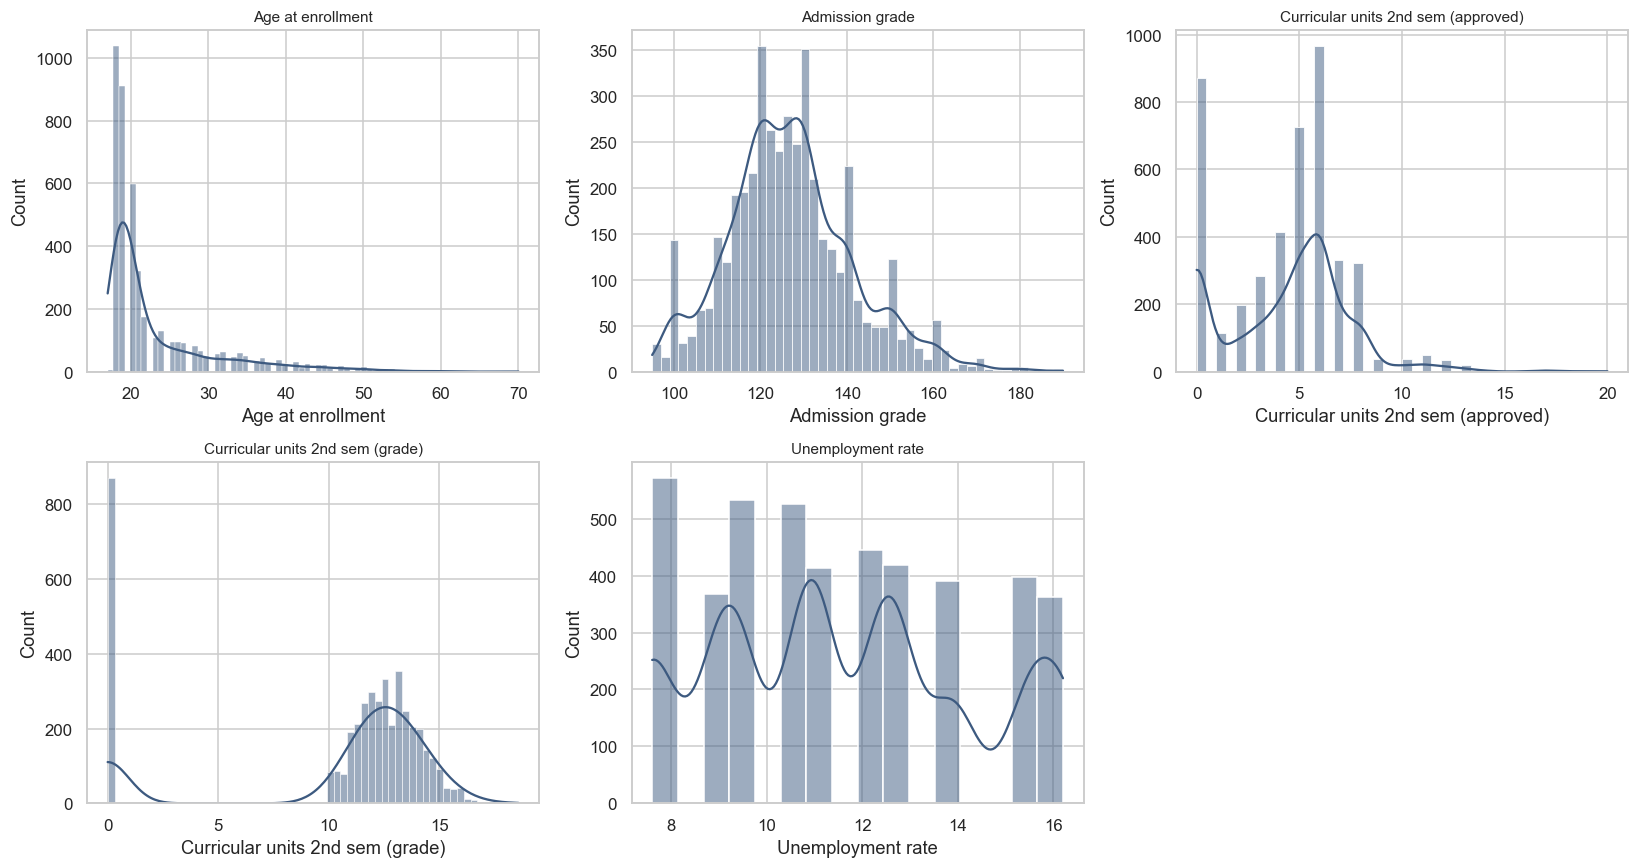

In [31]:
# Histogramas de las variables numéricas (seaborn)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, variables_numericas):
    sns.histplot(df[col], kde=True, color='#3d5a80', ax=ax)
    ax.set_title(col, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('fig1_histogramas_numericas.png', dpi=150)
plt.show()

**Lectura de la descriptiva:** la edad de ingreso está fuertemente asimétrica a la derecha (mayoría 18-25 años, cola hasta 70). La nota de admisión (escala 0-200) es razonablemente simétrica en torno a 127. Las unidades curriculares del 2do semestre (approved y grade) muestran un pico marcado en 0, señal temprana de riesgo de deserción, no error de datos.

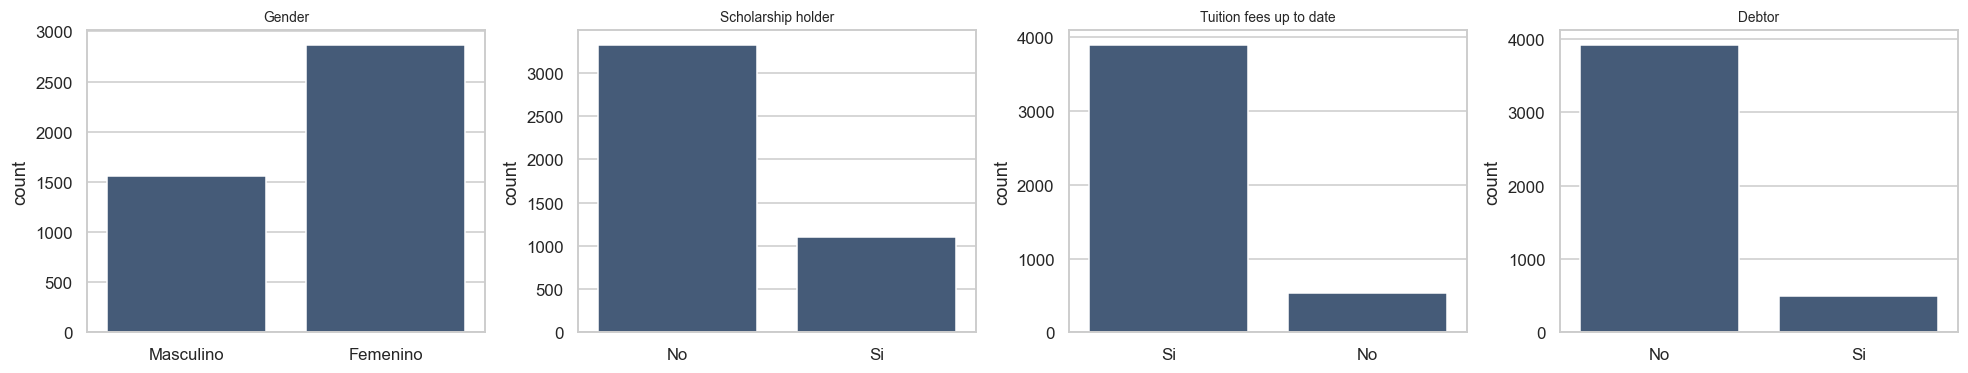

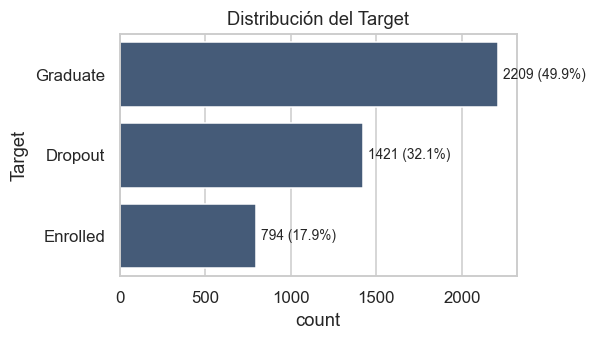

In [32]:
# Variables categóricas y Target (seaborn countplot)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
etiquetas = {'Gender': {0: 'Femenino', 1: 'Masculino'}, 'Scholarship holder': {0: 'No', 1: 'Si'},
             'Tuition fees up to date': {0: 'No', 1: 'Si'}, 'Debtor': {0: 'No', 1: 'Si'}}
for ax, col in zip(axes, etiquetas):
    sns.countplot(x=df[col].map(etiquetas[col]), color='#3d5a80', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('fig2_categoricas.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 3.2))
orden = df['Target'].value_counts().index
sns.countplot(y=df['Target'], order=orden, color='#3d5a80', ax=ax)
total = len(df)
for i, cat in enumerate(orden):
    v = (df['Target'] == cat).sum()
    ax.text(v + 30, i, f'{v} ({v/total*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Distribución del Target')
plt.tight_layout()
plt.savefig('fig3_target.png', dpi=150)
plt.show()

**Lectura:** el 88,6% de los estudiantes son solteros (estado civil). La distribución del Target confirma el desbalance de clases: Graduate 49,9% (2.209), Dropout 32,1% (1.421), Enrolled 17,9% (794).

### Análisis bivariado

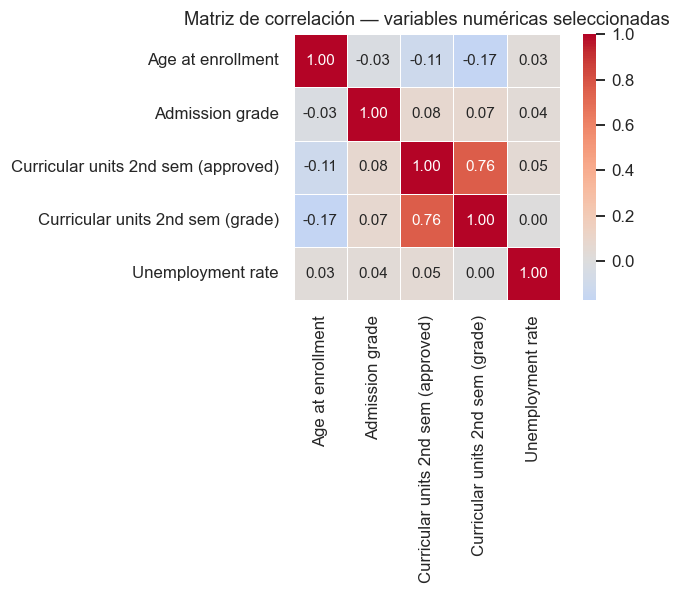

In [33]:
# Bivariado 1: Numérica-Numérica — matriz de correlación (heatmap)
corr_matrix = df[variables_numericas].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de correlación — variables numéricas seleccionadas')
plt.tight_layout()
plt.savefig('fig4_heatmap_correlacion.png', dpi=150)
plt.show()

**Lectura:** la única correlación relevante es entre "Curricular units 2nd sem (approved)" y "(grade)" (r=0,76), esperable dado que ambas miden desempeño académico del mismo período. El resto de los pares numéricos presenta correlaciones débiles (|r|<0,17).

=== TABLA CRUZADA: Debtor vs Target (% por fila) ===
Target_binario  Dropout  No-Dropout
Debtor                             
No deudor          28.3        71.7
Deudor             62.0        38.0


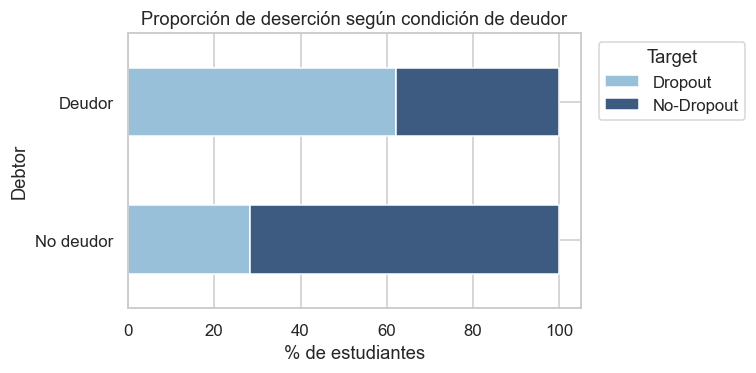

In [34]:
# Bivariado 2: Categórica-Categórica — Debtor x Target (agrupado)
df['Target_binario'] = df['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'No-Dropout')

tabla_debtor = pd.crosstab(df['Debtor'], df['Target_binario'], normalize='index') * 100
tabla_debtor.index = tabla_debtor.index.map({0: 'No deudor', 1: 'Deudor'})
print("=== TABLA CRUZADA: Debtor vs Target (% por fila) ===")
print(tabla_debtor.round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
tabla_debtor.plot(kind='barh', stacked=True, color=['#98c1d9', '#3d5a80'], ax=ax)
ax.set_xlabel('% de estudiantes')
ax.set_title('Proporción de deserción según condición de deudor')
ax.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig5_debtor_target.png', dpi=150)
plt.show()

**Lectura:** el 62,0% de los estudiantes deudores desertan, versus 28,3% de los no deudores, brecha de 33,7 puntos porcentuales, que refuerza la señal financiero-administrativa.

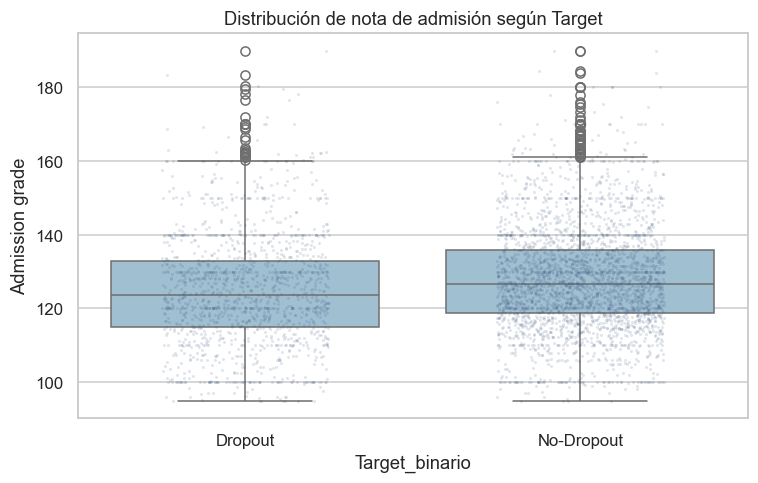

In [35]:
# Bivariado 3: Numérica-Categórica — Admission grade x Target (boxplot)
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='Target_binario', y='Admission grade', color='#98c1d9')
sns.stripplot(data=df, x='Target_binario', y='Admission grade', color='#3d5a80',
              alpha=0.15, size=2, jitter=0.25)
plt.title('Distribución de nota de admisión según Target')
plt.tight_layout()
plt.savefig('fig6_boxplot_admision.png', dpi=150)
plt.show()

In [36]:
# Tasa de deserción por categoría (tabla complementaria)
df['Dropout_bin'] = (df['Target'] == 'Dropout').astype(int)

print("=== TASA DE DROPOUT (%) POR CATEGORÍA ===")
for col in ['Gender', 'Scholarship holder', 'Tuition fees up to date', 'Debtor']:
    tasa = df.groupby(col)['Dropout_bin'].mean().mul(100).round(1)
    print(f'{col}: {dict(tasa)}')

=== TASA DE DROPOUT (%) POR CATEGORÍA ===
Gender: {0: np.float64(25.1), 1: np.float64(45.1)}
Scholarship holder: {0: np.float64(38.7), 1: np.float64(12.2)}
Tuition fees up to date: {0: np.float64(86.6), 1: np.float64(24.7)}
Debtor: {0: np.float64(28.3), 1: np.float64(62.0)}


**Lectura conjunta del bivariado:** la nota de admisión muestra distribuciones similares entre Dropout y No-Dropout (numérica-categórica), sugiriendo que el desempeño académico previo discrimina más débilmente la deserción que las variables financiero-administrativas (categórica-categórica), consistente con la ausencia de correlaciones fuertes entre variables numéricas no relacionadas al mismo semestre (numérica-numérica).

## 3. Estimación de parámetros

Se estiman tres parámetros poblacionales con un nivel de confianza del 95%, usando la distribución t para las medias (σ desconocida) y la aproximación normal para la proporción (n grande, justificado por el TLC).

In [37]:
def ic_media(datos, confianza=0.95):
    n = len(datos)
    x_bar = datos.mean()
    s = datos.std(ddof=1)
    se = s / np.sqrt(n)
    t_crit = stats.t.ppf(1 - (1 - confianza) / 2, df=n - 1)
    me = t_crit * se
    return x_bar, (x_bar - me, x_bar + me), se

def ic_proporcion(exitos, n, confianza=0.95):
    p_hat = exitos / n
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    z_crit = stats.norm.ppf(1 - (1 - confianza) / 2)
    me = z_crit * se
    return p_hat, (p_hat - me, p_hat + me), se

print("=== ESTIMACIÓN PUNTUAL E IC 95% ===\n")

x_bar, ic, se = ic_media(df['Age at enrollment'])
print(f"Edad media: {x_bar:.2f} años | IC 95%: [{ic[0]:.2f}, {ic[1]:.2f}] | SE={se:.4f}")

x_bar, ic, se = ic_media(df['Curricular units 2nd sem (grade)'])
print(f"Nota media 2do semestre: {x_bar:.2f} | IC 95%: [{ic[0]:.2f}, {ic[1]:.2f}] | SE={se:.4f}")

exitos = (df['Target'] == 'Dropout').sum()
p_hat, ic, se = ic_proporcion(exitos, len(df))
print(f"Proporción de Dropout: {p_hat*100:.2f}% | IC 95%: [{ic[0]*100:.2f}%, {ic[1]*100:.2f}%] | SE={se:.5f}")

=== ESTIMACIÓN PUNTUAL E IC 95% ===

Edad media: 23.27 años | IC 95%: [23.04, 23.49] | SE=0.1141
Nota media 2do semestre: 10.23 | IC 95%: [10.08, 10.38] | SE=0.0783
Proporción de Dropout: 32.12% | IC 95%: [30.74%, 33.50%] | SE=0.00702


**Limitaciones:** los IC asumen muestreo aleatorio de una población teórica más amplia; en rigor, el dataset es un censo de la cohorte 2008-2019 de esta institución específica, por lo que la generalización a otras instituciones o períodos debe hacerse con cautela. El IC de la nota media 2do semestre no distingue entre ceros genuinos (reprobación total) y posibles casos de deserción temprana dentro del mismo semestre, lo que podría sesgar la estimación hacia abajo.

## 4. Pruebas de hipótesis

Se agrupó el Target en dos categorías —Dropout versus No-Dropout (uniendo Enrolled y Graduate)— y se aplicaron dos pruebas con α=0,05.

In [38]:
print("="*70)
print("TEST 1: t de Welch — Edad de ingreso")
print("H0: media(Dropout) = media(No-Dropout)  |  H1: media(Dropout) != media(No-Dropout)")
print("="*70)

grupo_dropout = df.loc[df['Target'] == 'Dropout', 'Age at enrollment']
grupo_no_dropout = df.loc[df['Target'] != 'Dropout', 'Age at enrollment']

# Verificación de supuestos
print(f"\nSupuestos:")
print(f"  n Dropout = {len(grupo_dropout)}, n No-Dropout = {len(grupo_no_dropout)} (ambos >> 30 -> TLC aplica)")
print(f"  Independencia: cada estudiante pertenece a un único grupo")
print(f"  Se usa Welch (equal_var=False) por diferencia de tamaños/varianzas entre grupos")

t_stat, p_val = stats.ttest_ind(grupo_dropout, grupo_no_dropout, equal_var=False)
media_d, media_nd = grupo_dropout.mean(), grupo_no_dropout.mean()
s_pooled = np.sqrt(((len(grupo_dropout)-1)*grupo_dropout.std(ddof=1)**2 +
                    (len(grupo_no_dropout)-1)*grupo_no_dropout.std(ddof=1)**2) /
                   (len(grupo_dropout) + len(grupo_no_dropout) - 2))
cohens_d = (media_d - media_nd) / s_pooled

print(f"\nResultado:")
print(f"  Media Dropout: {media_d:.2f} años (n={len(grupo_dropout)})")
print(f"  Media No-Dropout: {media_nd:.2f} años (n={len(grupo_no_dropout)})")
print(f"  t = {t_stat:.2f}, p = {p_val:.2e}")
print(f"  Cohen's d = {cohens_d:.3f}")
print('  Conclusión: se rechaza H0 (p < 0.05)' if p_val < 0.05 else '  Conclusión: no se rechaza H0')

TEST 1: t de Welch — Edad de ingreso
H0: media(Dropout) = media(No-Dropout)  |  H1: media(Dropout) != media(No-Dropout)

Supuestos:
  n Dropout = 1421, n No-Dropout = 3003 (ambos >> 30 -> TLC aplica)
  Independencia: cada estudiante pertenece a un único grupo
  Se usa Welch (equal_var=False) por diferencia de tamaños/varianzas entre grupos

Resultado:
  Media Dropout: 26.07 años (n=1421)
  Media No-Dropout: 21.94 años (n=3003)
  t = 15.86, p = 9.20e-54
  Cohen's d = 0.563
  Conclusión: se rechaza H0 (p < 0.05)


In [39]:
print("="*70)
print("TEST 2: Chi-cuadrado de independencia — Estado de pago de matrícula")
print("H0: independencia entre las variables  |  H1: asociación entre las variables")
print("="*70)

tabla_contingencia = pd.crosstab(df['Tuition fees up to date'], df['Dropout_bin'])
print("\nTabla de contingencia:")
print(tabla_contingencia)

chi2, p_val2, gl, esperado = stats.chi2_contingency(tabla_contingencia)
n_total = tabla_contingencia.sum().sum()
cramer_v = np.sqrt(chi2 / (n_total * (min(tabla_contingencia.shape) - 1)))

print(f"\nSupuestos:")
print(f"  Ambas variables categóricas binarias; observaciones independientes")
print(f"  Frecuencias esperadas (mínimo debe ser >= 5):")
print(f"  {esperado.round(1)}")
print(f"  Frecuencia esperada mínima: {esperado.min():.1f} (muy sobre el umbral de 5)")

print(f"\nResultado:")
print(f"  chi2 = {chi2:.2f}, gl = {gl}, p = {p_val2:.2e}")
print(f"  V de Cramér = {cramer_v:.3f}")
print('  Conclusión: se rechaza H0 (p < 0.05)' if p_val2 < 0.05 else '  Conclusión: no se rechaza H0')

TEST 2: Chi-cuadrado de independencia — Estado de pago de matrícula
H0: independencia entre las variables  |  H1: asociación entre las variables

Tabla de contingencia:
Dropout_bin                 0    1
Tuition fees up to date           
0                          71  457
1                        2932  964

Supuestos:
  Ambas variables categóricas binarias; observaciones independientes
  Frecuencias esperadas (mínimo debe ser >= 5):
  [[ 358.4  169.6]
 [2644.6 1251.4]]
  Frecuencia esperada mínima: 169.6 (muy sobre el umbral de 5)

Resultado:
  chi2 = 811.93, gl = 1, p = 1.37e-178
  V de Cramér = 0.428
  Conclusión: se rechaza H0 (p < 0.05)


**Interpretación conjunta.** Ambas pruebas rechazan H0 con p < 0,0001. La edad separa los grupos con un efecto moderado (d=0,563): quienes desertan ingresan, en promedio, ~4 años más grandes. El estado de pago de matrícula tiene una asociación considerablemente más fuerte (V de Cramér=0,428): la deserción es varias veces más frecuente entre quienes no tienen la matrícula al día. En términos relativos, el pago de matrícula discrimina la deserción con más fuerza que la edad.

## 5. Informe de avance del proyecto

**Metodología aplicada:** análisis realizado en Python 3.11.15 (entorno virtual local), con las librerías pandas, numpy, scipy, matplotlib y seaborn. Se fijó la semilla en **123456** para reproducibilidad.

**Hallazgos principales:**
1. El comportamiento financiero-administrativo (pago de matrícula al día, condición de deudor) discrimina la deserción con más fuerza que las variables demográficas. Las señales de riesgo más tempranas y accionables podrían estar en el ámbito de gestión financiera estudiantil, no solo en el perfil sociodemográfico.
2. La edad de ingreso aporta una señal adicional, moderada: estudiantes que ingresan mayores (~26 años en promedio entre quienes desertan, vs. ~22 entre quienes no) presentan mayor riesgo, posiblemente asociado a responsabilidades externas (laborales o familiares) que compiten con el tiempo de estudio.

**Próximos pasos del proyecto:**
- Fase de modelamiento: evaluar si priorizar variables financiero-administrativas por sobre las demográficas, dado su mayor poder discriminativo observado.
- Usar métricas de evaluación sensibles a la clase minoritaria (no solo exactitud), dado el desbalance del Target (32,1% Dropout).
- Evitar incluir simultáneamente "approved" y "grade" del mismo semestre sin tratar la colinealidad (r=0,76).

## 6. Notebook y repositorio GitHub (6 pts)

Este notebook (`Sumativa1_MCDI501_Codigo.ipynb`) corre de principio a fin sin errores (Kernel → Restart & Run All), con semilla fija para reproducibilidad, y está organizado en los mismos 7 bloques del informe Word para asegurar trazabilidad. El repositorio GitHub del proyecto —enlazado en el encabezado de este notebook y del informe— contiene este notebook, el dataset y el informe en PDF.

## 7. Bibliografía (APA 7)

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89